In [ ]:
import numpy as np
if not hasattr(np, 'float'):
    np.float = float  # Aliases np.float back to the standard python float

In [ ]:
import numpy as np
import pandas as pd
import torch
from pytorch_forecasting import TimeSeriesDataSet

# =====================================================================
# CONFIGURATION
# =====================================================================
MAX_ENCODER_LEN = 6
MAX_PRED_LEN = 3
TRAIN_END_YEAR = 2020
TARGET = "log_total_emission"

# =====================================================================
# HELPER FUNCTIONS
# =====================================================================

def add_lag_features(df):
    """Add lag features needed by TFT"""
    df = df.sort_values(["Area", "Year"])
    
    df["lag1"] = df.groupby("Area")[TARGET].shift(1)
    df["lag2"] = df.groupby("Area")[TARGET].shift(2)
    df["roll3"] = (
        df.groupby("Area")[TARGET]
          .rolling(3, min_periods=1).mean()
          .reset_index(level=0, drop=True)
    )
    df["delta"] = df[TARGET] - df["lag1"]
    
    return df.fillna(0)


def prepare_forecast_data(historical_df, scenario_df, shift_amt):
    """
    Prepare data for multi-step forecasting.
    
    Args:
        historical_df: DataFrame with complete historical data (1990-2020)
        scenario_df: DataFrame with future scenario data (2021-2100)
        shift_amt: Amount used in log transformation
    
    Returns:
        DataFrame ready for TFT forecasting
    """
    # Mark future scenario rows with NaN target
    scenario_df = scenario_df.copy()
    scenario_df[TARGET] = np.nan
    
    # Combine historical + future
    combined = pd.concat([historical_df, scenario_df], ignore_index=True)
    combined = combined.sort_values(["Area", "Year"]).reset_index(drop=True)
    
    # Add lag features
    combined = add_lag_features(combined)
    
    # Add TFT required fields
    combined["group_id"] = combined["Area"].astype(str)
    combined["time_idx"] = combined.groupby("Area").cumcount()
    
    return combined


def rolling_window_forecast_single_country(model, training_data, country_data, 
                                           start_year=2021, end_year=2100, 
                                           pred_length=3, shift_amt=0):
    """
    Rolling window forecast for a single country.
    More reliable than batch processing.
    """
    country_name = country_data["Area"].iloc[0]
    predictions = []
    
    # Work with a copy
    working_data = country_data.copy()
    
    current_year = start_year
    iteration = 0
    
    while current_year <= end_year:
        iteration += 1
        years_to_predict = min(pred_length, end_year - current_year + 1)
        
        # Get all data up to (but not including) current_year
        historical_data = working_data[working_data["Year"] < current_year].copy()
        
        # Check if we have enough historical data
        if len(historical_data) < MAX_ENCODER_LEN:
            print(f"    ⚠️  {country_name}: Not enough history at year {current_year} (need {MAX_ENCODER_LEN}, have {len(historical_data)})")
            break
        
        try:
            # Create forecast dataset
            forecast_dataset = TimeSeriesDataSet.from_dataset(
                training_data,
                historical_data,
                predict=True,
                stop_randomization=True
            )
            
            # Check if dataset is valid
            if len(forecast_dataset) == 0:
                print(f"    ⚠️  {country_name}: Empty dataset at year {current_year}")
                break
            
            # Create dataloader
            forecast_dl = forecast_dataset.to_dataloader(
                train=False, 
                batch_size=1,  # Single country at a time
                num_workers=0
            )
            
            # Get predictions
            with torch.no_grad():
                raw_preds = model.predict(forecast_dl).numpy()
            
            # raw_preds shape: (1, pred_length) for single country
            preds_log = raw_preds[0]  # Get first (and only) sample
            
            # Convert from log space to actual emissions
            preds_actual = np.exp(preds_log[:years_to_predict]) - shift_amt
            preds_log_slice = preds_log[:years_to_predict]
            
            # Store predictions
            for i in range(years_to_predict):
                year = current_year + i
                predictions.append({
                    "Area": country_name,
                    "Year": year,
                    "predicted_log_emission": float(preds_log_slice[i]),
                    "predicted_emissions": float(preds_actual[i])
                })
                
                # Update working_data with this prediction for next iteration
                year_mask = working_data["Year"] == year
                working_data.loc[year_mask, TARGET] = preds_log_slice[i]
            
            # Recalculate lag features with updated predictions
            working_data = add_lag_features(working_data)
            
            # Move window forward
            current_year += years_to_predict
            
        except Exception as e:
            print(f"    ❌ {country_name}: Error at year {current_year}: {str(e)}")
            break
    
    return pd.DataFrame(predictions)


def rolling_window_forecast_all_countries(model, training_data, scenario_combined,
                                         start_year=2021, end_year=2100,
                                         pred_length=3, shift_amt=0):
    """
    Forecast all countries using rolling window approach.
    """
    all_countries = sorted(scenario_combined["Area"].unique())
    total_countries = len(all_countries)
    
    print(f"\n{'='*70}")
    print(f"Starting Rolling Window Forecast")
    print(f"{'='*70}")
    print(f"Countries to forecast: {total_countries}")
    print(f"Forecast period: {start_year} - {end_year}")
    print(f"Prediction window: {pred_length} years")
    print(f"{'='*70}\n")
    
    all_forecasts = []
    successful_countries = 0
    failed_countries = []
    
    for idx, country in enumerate(all_countries, 1):
        print(f"[{idx}/{total_countries}] Forecasting {country}...", end=" ")
        
        try:
            # Get country-specific data
            country_data = scenario_combined[scenario_combined["Area"] == country].copy()
            
            # Forecast this country
            country_forecast = rolling_window_forecast_single_country(
                model=model,
                training_data=training_data,
                country_data=country_data,
                start_year=start_year,
                end_year=end_year,
                pred_length=pred_length,
                shift_amt=shift_amt
            )
            
            if len(country_forecast) > 0:
                all_forecasts.append(country_forecast)
                successful_countries += 1
                print(f"✅ ({len(country_forecast)} predictions)")
            else:
                failed_countries.append(country)
                print(f"❌ (0 predictions)")
                
        except Exception as e:
            failed_countries.append(country)
            print(f"❌ Error: {str(e)}")
    
    # Combine all forecasts
    if len(all_forecasts) > 0:
        final_forecast = pd.concat(all_forecasts, ignore_index=True)
    else:
        final_forecast = pd.DataFrame(columns=["Area", "Year", "predicted_log_emission", "predicted_emissions"])
    
    # Summary
    print(f"\n{'='*70}")
    print(f"Forecast Summary")
    print(f"{'='*70}")
    print(f"✅ Successful: {successful_countries}/{total_countries} countries")
    print(f"📊 Total predictions: {len(final_forecast):,}")
    
    if failed_countries:
        print(f"\n❌ Failed countries ({len(failed_countries)}):")
        for country in failed_countries[:10]:  # Show first 10
            print(f"   - {country}")
        if len(failed_countries) > 10:
            print(f"   ... and {len(failed_countries) - 10} more")
    
    print(f"{'='*70}\n")
    
    return final_forecast


# =====================================================================
# MAIN EXECUTION
# =====================================================================

# Load data
df_train = pd.read_csv("agro_co2_train.csv")
df_test = pd.read_csv("agro_co2_test.csv")
df_all = pd.concat([df_train, df_test], ignore_index=True)
df_all = df_all.sort_values(["Area", "Year"]).reset_index(drop=True)

# Calculate shift amount
shift_amt = max(1 - df_all["total_emission"].min(), 0)
df_all["total_emission_shifted"] = df_all["total_emission"] + shift_amt
df_all[TARGET] = np.log(df_all["total_emission_shifted"])

# Add lag features to historical data
df_all = add_lag_features(df_all)
df_all["group_id"] = df_all["Area"].astype(str)
df_all["time_idx"] = df_all.groupby("Area").cumcount()

# Recreate your training dataset (needed for from_dataset())
training_data = TimeSeriesDataSet(
    df_all[df_all["Year"] <= TRAIN_END_YEAR],
    time_idx="time_idx",
    target=TARGET,
    group_ids=["group_id"],
    max_encoder_length=MAX_ENCODER_LEN,
    max_prediction_length=MAX_PRED_LEN,
    static_categoricals=["group_id"],
    time_varying_known_reals=["Year"] + [f for f in numerical_drivers if f != "Year"],
    time_varying_unknown_reals=[TARGET, "lag1", "lag2", "roll3", "delta"],
    target_normalizer=GroupNormalizer(groups=["group_id"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Load scenarios
scenario_base = pd.read_csv("future_scenarios_country.csv")
scenarioA_df = scenario_base[scenario_base["scenario"] == "A"]
scenarioB_df = scenario_base[scenario_base["scenario"] == "B"]
scenarioBaseline_df = scenario_base[scenario_base["scenario"] == "Baseline"]

# Prepare forecast data
scenarioA_combined = prepare_forecast_data(
    df_all[df_all["Year"] <= TRAIN_END_YEAR], 
    scenarioA_df, 
    shift_amt
)

scenarioB_combined = prepare_forecast_data(
    df_all[df_all["Year"] <= TRAIN_END_YEAR], 
    scenarioB_df, 
    shift_amt
)

scenarioBase_combined = prepare_forecast_data(
    df_all[df_all["Year"] <= TRAIN_END_YEAR], 
    scenarioBaseline_df, 
    shift_amt
)

# =====================================================================
# RUN ROLLING WINDOW FORECASTS
# =====================================================================

# Scenario A
print("\n" + "="*70)
print("SCENARIO A FORECAST")
print("="*70)
forecast_A = rolling_window_forecast_all_countries(
    model=best_tft,
    training_data=training_data,
    scenario_combined=scenarioA_combined,
    start_year=2021,
    end_year=2100,
    pred_length=MAX_PRED_LEN,
    shift_amt=shift_amt
)

# Scenario B
print("\n" + "="*70)
print("SCENARIO B FORECAST")
print("="*70)
forecast_B = rolling_window_forecast_all_countries(
    model=best_tft,
    training_data=training_data,
    scenario_combined=scenarioB_combined,
    start_year=2021,
    end_year=2100,
    pred_length=MAX_PRED_LEN,
    shift_amt=shift_amt
)

# Baseline Scenario
print("\n" + "="*70)
print("BASELINE SCENARIO FORECAST")
print("="*70)
forecast_Base = rolling_window_forecast_all_countries(
    model=best_tft,
    training_data=training_data,
    scenario_combined=scenarioBase_combined,
    start_year=2021,
    end_year=2100,
    pred_length=MAX_PRED_LEN,
    shift_amt=shift_amt
)

# =====================================================================
# SAVE RESULTS
# =====================================================================
forecast_A.to_csv("tft_forecast_scenarioA_2021_2100.csv", index=False)
forecast_B.to_csv("tft_forecast_scenarioB_2021_2100.csv", index=False)
forecast_Base.to_csv("tft_forecast_baseline_2021_2100.csv", index=False)

print("\n" + "="*70)
print("ALL FORECASTS COMPLETED AND SAVED")
print("="*70)
print(f"✅ Scenario A: {len(forecast_A):,} predictions → tft_forecast_scenarioA_2021_2100.csv")
print(f"✅ Scenario B: {len(forecast_B):,} predictions → tft_forecast_scenarioB_2021_2100.csv")
print(f"✅ Baseline: {len(forecast_Base):,} predictions → tft_forecast_baseline_2021_2100.csv")
print("="*70 + "\n")

/opt/anaconda3/envs/acad/lib/python3.10/site-packages/pytorch_forecasting/data/timeseries.py:1282: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 5 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__group_id': 'Czechoslovakia'}, {'__group_id__group_id': 'Ethiopia PDR'}, {'__group_id__group_id': 'Pacific Islands Trust Territory'}, {'__group_id__group_id': 'USSR'}, {'__group_id__group_id': 'Yugoslav SFR'}]
  warnings.warn(



SCENARIO A FORECAST

Starting Rolling Window Forecast
Countries to forecast: 236
Forecast period: 2021 - 2100
Prediction window: 3 years

[1/236] Forecasting Afghanistan... ✅ (80 predictions)
[2/236] Forecasting Albania... ✅ (80 predictions)
[3/236] Forecasting Algeria... ✅ (80 predictions)
[4/236] Forecasting American Samoa... ✅ (80 predictions)
[5/236] Forecasting Andorra... ✅ (80 predictions)
[6/236] Forecasting Angola... ✅ (80 predictions)
[7/236] Forecasting Anguilla... ✅ (80 predictions)
[8/236] Forecasting Antigua and Barbuda... ✅ (80 predictions)
[9/236] Forecasting Argentina... ✅ (80 predictions)
[10/236] Forecasting Armenia... ✅ (80 predictions)
[11/236] Forecasting Aruba... ✅ (80 predictions)
[12/236] Forecasting Australia... ✅ (80 predictions)
[13/236] Forecasting Austria... ✅ (80 predictions)
[14/236] Forecasting Azerbaijan... ✅ (80 predictions)
[15/236] Forecasting Bahamas... ✅ (80 predictions)
[16/236] Forecasting Bahrain... ✅ (80 predictions)
[17/236] Forecasting Bangl

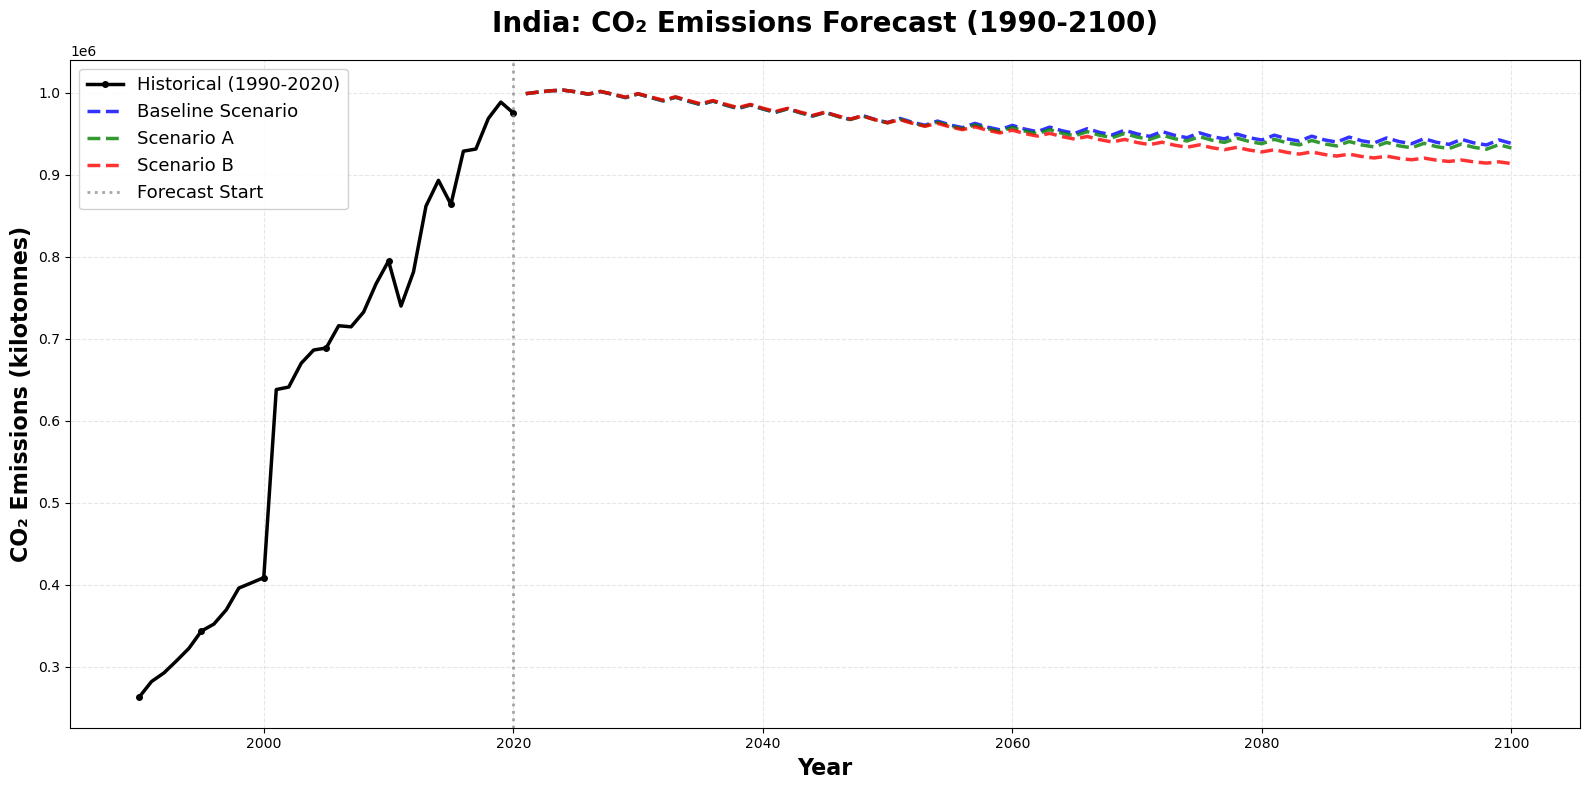

✅ Plot 1 saved: india_emissions_full_timeline.png


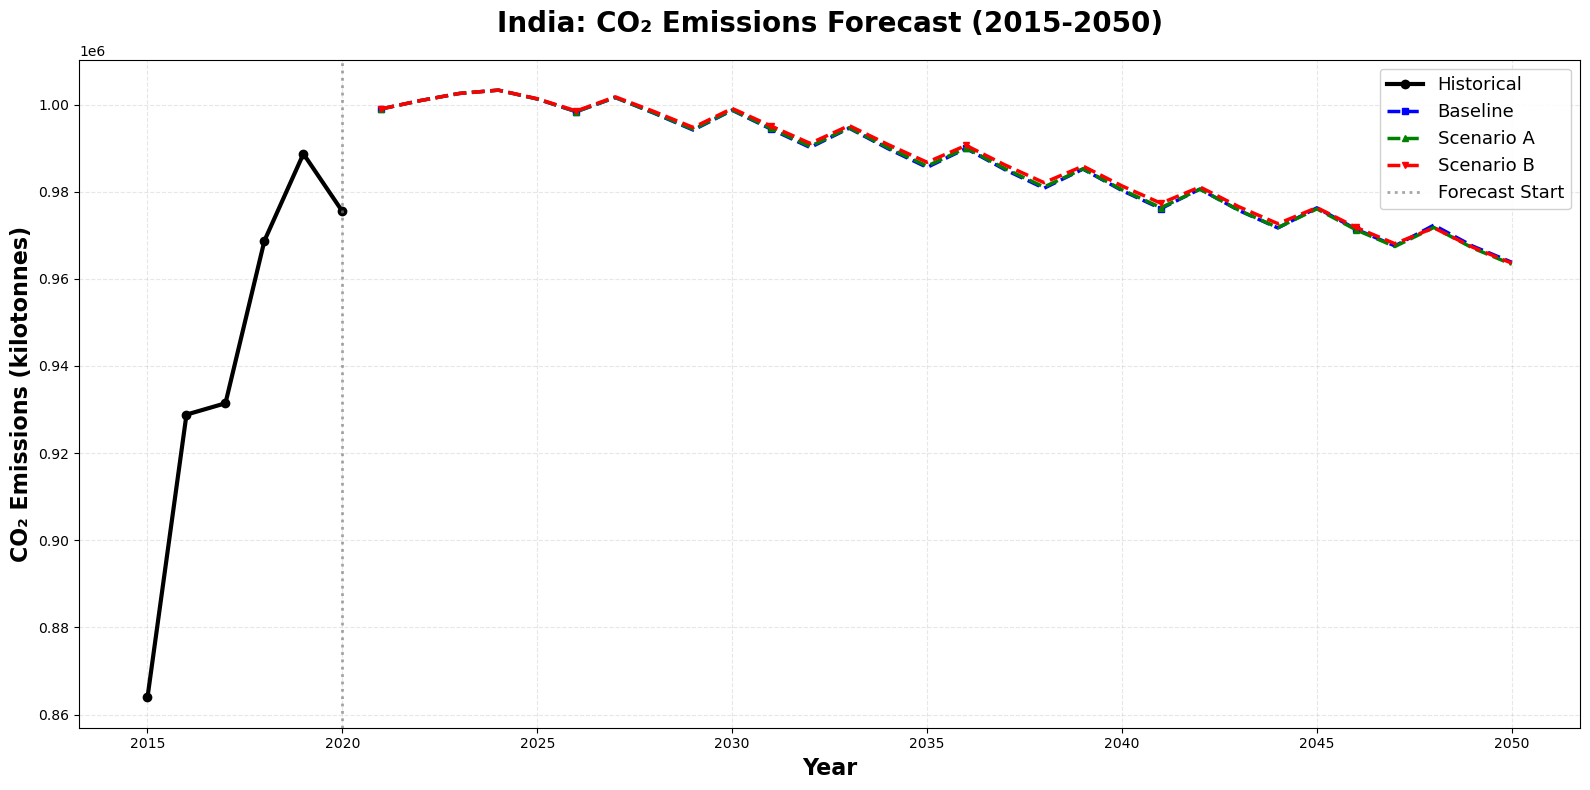

✅ Plot 2 saved: india_emissions_2015_2050.png


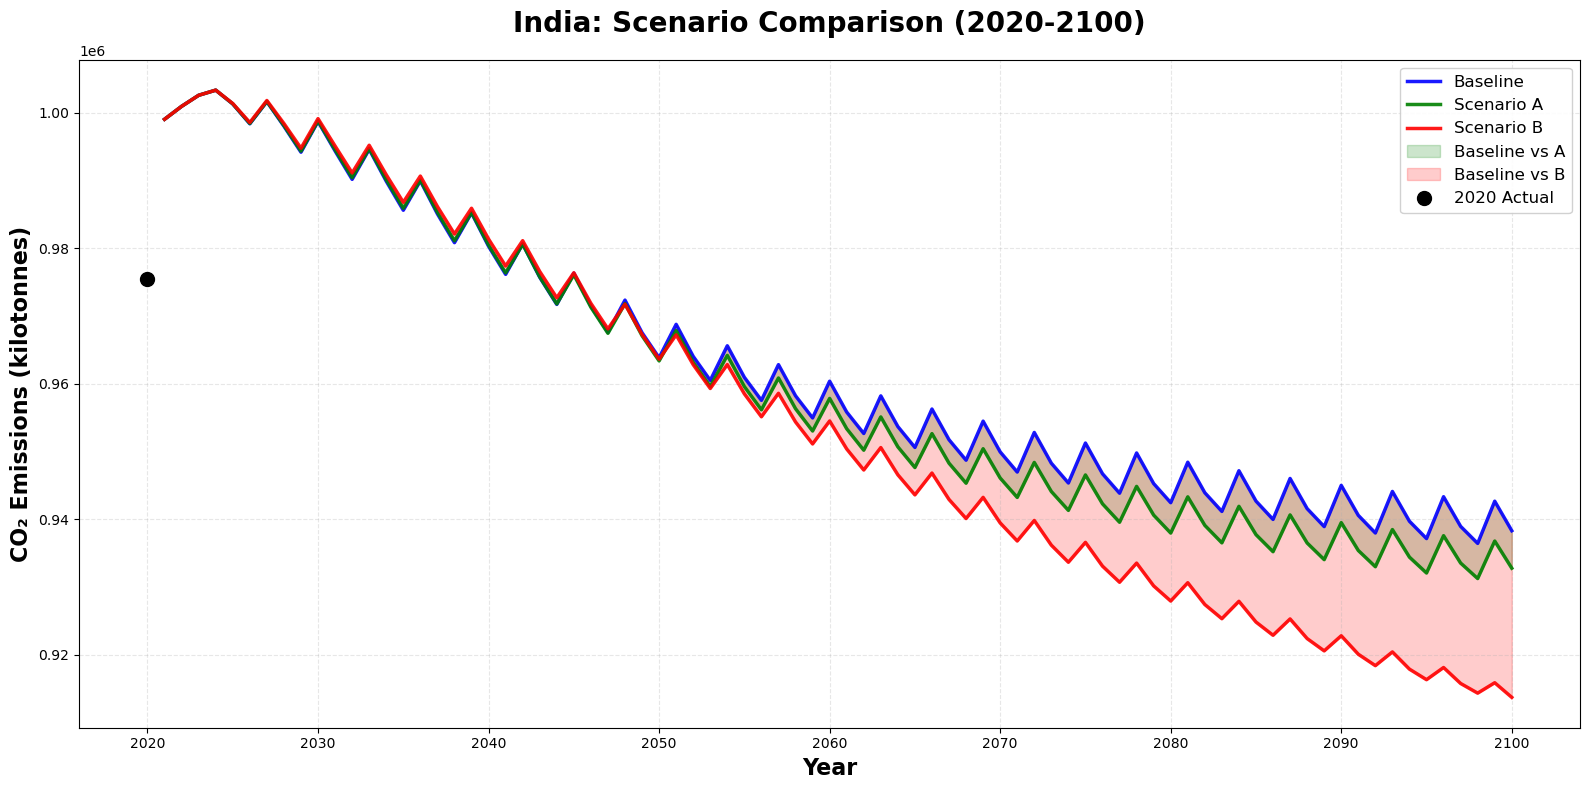

✅ Plot 3 saved: india_scenarios_comparison.png

INDIA EMISSIONS SUMMARY

📊 Historical (1990-2020):
   Starting (1990): 262,529
   Ending (2020): 975,466
   Average: 636,140

📈 Year 2030:
   Baseline:   998,683
   Scenario A: 998,769
   Scenario B: 999,096

📈 Year 2050:
   Baseline:   963,803
   Scenario A: 963,341
   Scenario B: 963,599

📈 Year 2075:
   Baseline:   951,216
   Scenario A: 946,512
   Scenario B: 936,560

📈 Year 2100:
   Baseline:   938,280
   Scenario A: 932,748
   Scenario B: 913,686

📉 Forecast Trends (2021-2100):
   Baseline:   999,001 → 938,280
   Scenario A: 999,001 → 932,748
   Scenario B: 999,001 → 913,686

✅ All plots generated successfully!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# LOAD DATA
# =====================================================================

# Historical data
df_hist = pd.read_csv("Agrofood_co2_emission_clean.csv")

# Forecast data (adjust filenames if needed)
forecast_A = pd.read_csv("tft_forecast_scenarioA_2021_2100.csv")
forecast_B = pd.read_csv("tft_forecast_scenarioB_2021_2100.csv")
forecast_Base = pd.read_csv("tft_forecast_baseline_2021_2100.csv")

# =====================================================================
# FILTER FOR INDIA
# =====================================================================

india_hist = df_hist[df_hist["Area"] == "India"].copy()
india_hist = india_hist.sort_values("Year")

india_A = forecast_A[forecast_A["Area"] == "India"].copy()
india_A = india_A.sort_values("Year")

india_B = forecast_B[forecast_B["Area"] == "India"].copy()
india_B = india_B.sort_values("Year")

india_Base = forecast_Base[forecast_Base["Area"] == "India"].copy()
india_Base = india_Base.sort_values("Year")

# =====================================================================
# PLOT 1: COMPLETE TIMELINE (1990-2100)
# =====================================================================

plt.figure(figsize=(16, 8))

# Historical data (black line)
plt.plot(
    india_hist["Year"], 
    india_hist["total_emission"], 
    color="black", 
    linewidth=2.5,
    label="Historical (1990-2020)",
    marker='o',
    markersize=4,
    markevery=5  # Show marker every 5 years
)

# Baseline forecast (blue)
plt.plot(
    india_Base["Year"], 
    india_Base["predicted_emissions"], 
    color="blue",
    linewidth=2.5,
    linestyle="--",
    label="Baseline Scenario",
    alpha=0.8
)

# Scenario A (green)
plt.plot(
    india_A["Year"], 
    india_A["predicted_emissions"], 
    color="green",
    linewidth=2.5,
    linestyle="--",
    label="Scenario A",
    alpha=0.8
)

# Scenario B (red)
plt.plot(
    india_B["Year"], 
    india_B["predicted_emissions"], 
    color="red",
    linewidth=2.5,
    linestyle="--",
    label="Scenario B",
    alpha=0.8
)

# Vertical line at forecast start
plt.axvline(x=2020, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Forecast Start')

# Formatting
plt.title("India: CO₂ Emissions Forecast (1990-2100)", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=16, fontweight='bold')
plt.ylabel("CO₂ Emissions (kilotonnes)", fontsize=16, fontweight='bold')
plt.legend(fontsize=13, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save figure
plt.savefig("india_emissions_full_timeline.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 1 saved: india_emissions_full_timeline.png")

# =====================================================================
# PLOT 2: ZOOM ON FORECAST PERIOD (2015-2050)
# =====================================================================

plt.figure(figsize=(16, 8))

# Historical data (last 5 years for context)
india_hist_recent = india_hist[india_hist["Year"] >= 2015]
plt.plot(
    india_hist_recent["Year"], 
    india_hist_recent["total_emission"], 
    color="black", 
    linewidth=3,
    label="Historical",
    marker='o',
    markersize=6
)

# Forecasts (filtered to 2050)
india_Base_zoom = india_Base[india_Base["Year"] <= 2050]
india_A_zoom = india_A[india_A["Year"] <= 2050]
india_B_zoom = india_B[india_B["Year"] <= 2050]

plt.plot(
    india_Base_zoom["Year"], 
    india_Base_zoom["predicted_emissions"], 
    color="blue",
    linewidth=2.5,
    linestyle="--",
    marker='s',
    markersize=5,
    markevery=5,
    label="Baseline"
)

plt.plot(
    india_A_zoom["Year"], 
    india_A_zoom["predicted_emissions"], 
    color="green",
    linewidth=2.5,
    linestyle="--",
    marker='^',
    markersize=5,
    markevery=5,
    label="Scenario A"
)

plt.plot(
    india_B_zoom["Year"], 
    india_B_zoom["predicted_emissions"], 
    color="red",
    linewidth=2.5,
    linestyle="--",
    marker='v',
    markersize=5,
    markevery=5,
    label="Scenario B"
)

plt.axvline(x=2020, color='gray', linestyle=':', linewidth=2, alpha=0.7, label='Forecast Start')

plt.title("India: CO₂ Emissions Forecast (2015-2050)", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=16, fontweight='bold')
plt.ylabel("CO₂ Emissions (kilotonnes)", fontsize=16, fontweight='bold')
plt.legend(fontsize=13, loc='best', framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig("india_emissions_2015_2050.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 2 saved: india_emissions_2015_2050.png")

# =====================================================================
# PLOT 3: SCENARIO COMPARISON (2020-2100)
# =====================================================================

fig, ax = plt.subplots(figsize=(16, 8))

# Plot forecasts only
ax.plot(india_Base["Year"], india_Base["predicted_emissions"], 
        'b-', linewidth=2.5, label="Baseline", alpha=0.9)
ax.plot(india_A["Year"], india_A["predicted_emissions"], 
        'g-', linewidth=2.5, label="Scenario A", alpha=0.9)
ax.plot(india_B["Year"], india_B["predicted_emissions"], 
        'r-', linewidth=2.5, label="Scenario B", alpha=0.9)

# Fill between scenarios to show divergence
ax.fill_between(india_Base["Year"], 
                india_Base["predicted_emissions"],
                india_A["predicted_emissions"],
                alpha=0.2, color='green', label='Baseline vs A')

ax.fill_between(india_Base["Year"], 
                india_Base["predicted_emissions"],
                india_B["predicted_emissions"],
                alpha=0.2, color='red', label='Baseline vs B')

# Add 2020 baseline point
last_hist = india_hist[india_hist["Year"] == 2020]["total_emission"].values[0]
ax.plot(2020, last_hist, 'ko', markersize=10, label='2020 Actual', zorder=5)

ax.set_title("India: Scenario Comparison (2020-2100)", fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel("Year", fontsize=16, fontweight='bold')
ax.set_ylabel("CO₂ Emissions (kilotonnes)", fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("india_scenarios_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Plot 3 saved: india_scenarios_comparison.png")

# =====================================================================
# SUMMARY STATISTICS
# =====================================================================

print("\n" + "="*70)
print("INDIA EMISSIONS SUMMARY")
print("="*70)

# Historical
print(f"\n📊 Historical (1990-2020):")
print(f"   Starting (1990): {india_hist[india_hist['Year']==1990]['total_emission'].values[0]:,.0f}")
print(f"   Ending (2020): {india_hist[india_hist['Year']==2020]['total_emission'].values[0]:,.0f}")
print(f"   Average: {india_hist['total_emission'].mean():,.0f}")

# Forecasts for key years
years_of_interest = [2030, 2050, 2075, 2100]

for year in years_of_interest:
    print(f"\n📈 Year {year}:")
    if year in india_Base["Year"].values:
        base_val = india_Base[india_Base["Year"]==year]["predicted_emissions"].values[0]
        print(f"   Baseline:   {base_val:,.0f}")
    
    if year in india_A["Year"].values:
        a_val = india_A[india_A["Year"]==year]["predicted_emissions"].values[0]
        print(f"   Scenario A: {a_val:,.0f}")
    
    if year in india_B["Year"].values:
        b_val = india_B[india_B["Year"]==year]["predicted_emissions"].values[0]
        print(f"   Scenario B: {b_val:,.0f}")

# Overall trends
print(f"\n📉 Forecast Trends (2021-2100):")
print(f"   Baseline:   {india_Base['predicted_emissions'].values[0]:,.0f} → {india_Base['predicted_emissions'].values[-1]:,.0f}")
print(f"   Scenario A: {india_A['predicted_emissions'].values[0]:,.0f} → {india_A['predicted_emissions'].values[-1]:,.0f}")
print(f"   Scenario B: {india_B['predicted_emissions'].values[0]:,.0f} → {india_B['predicted_emissions'].values[-1]:,.0f}")

print("\n" + "="*70)
print("✅ All plots generated successfully!")

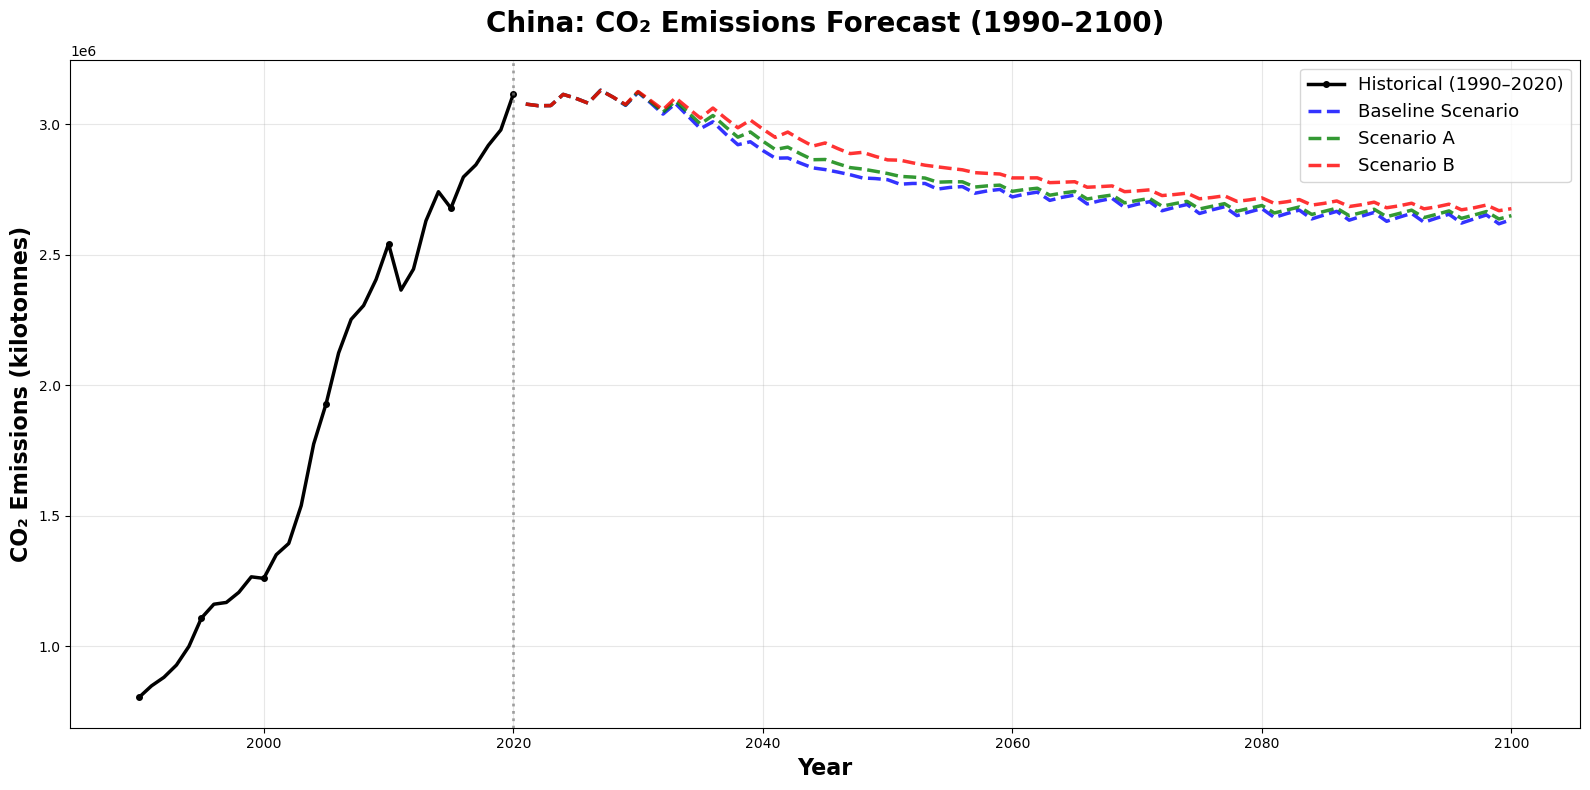

✅ Saved: china_emissions_1990_2100.png


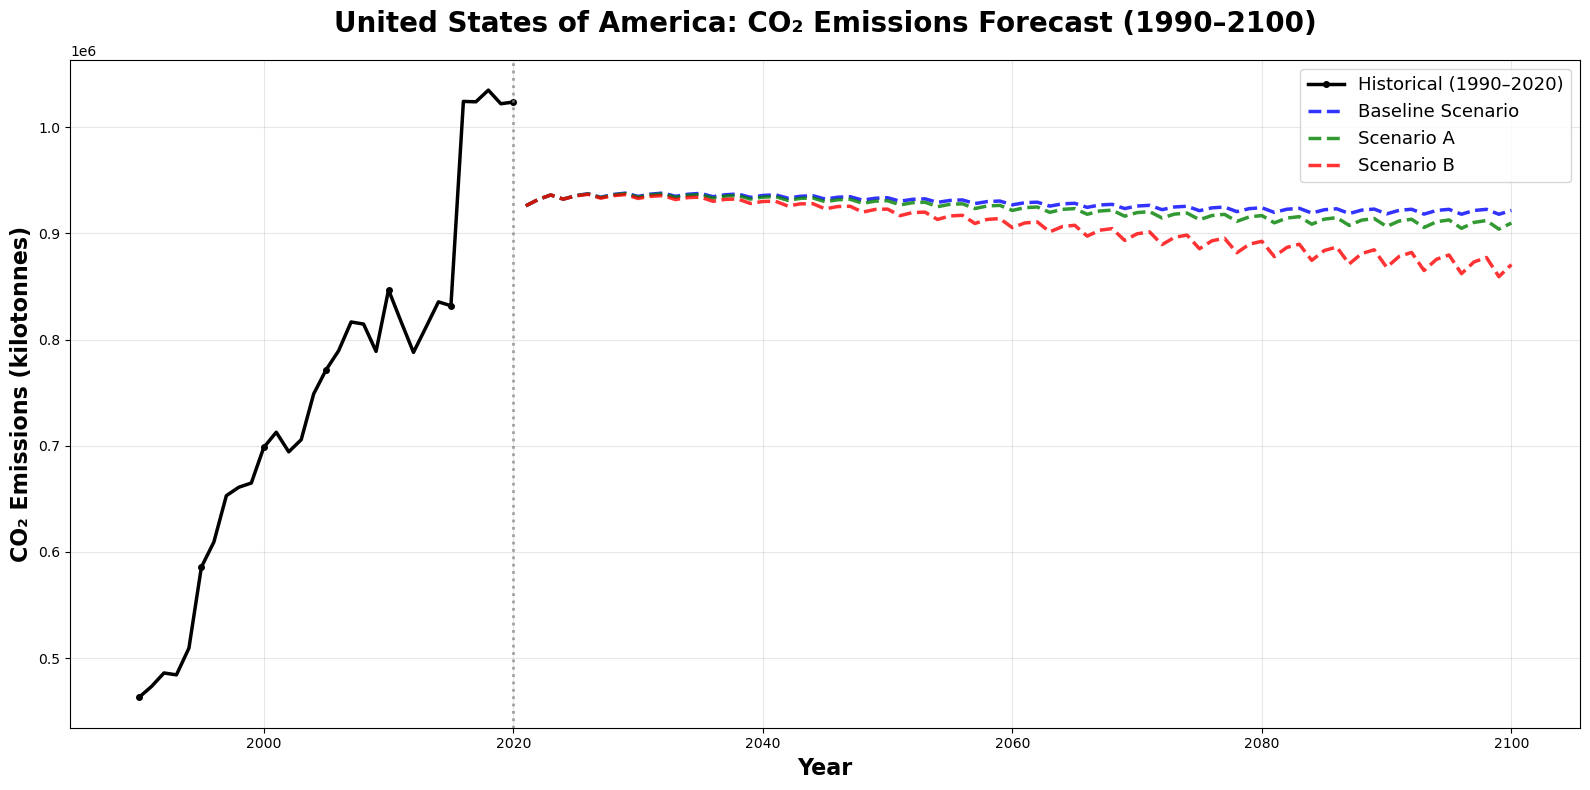

✅ Saved: united_states_of_america_emissions_1990_2100.png


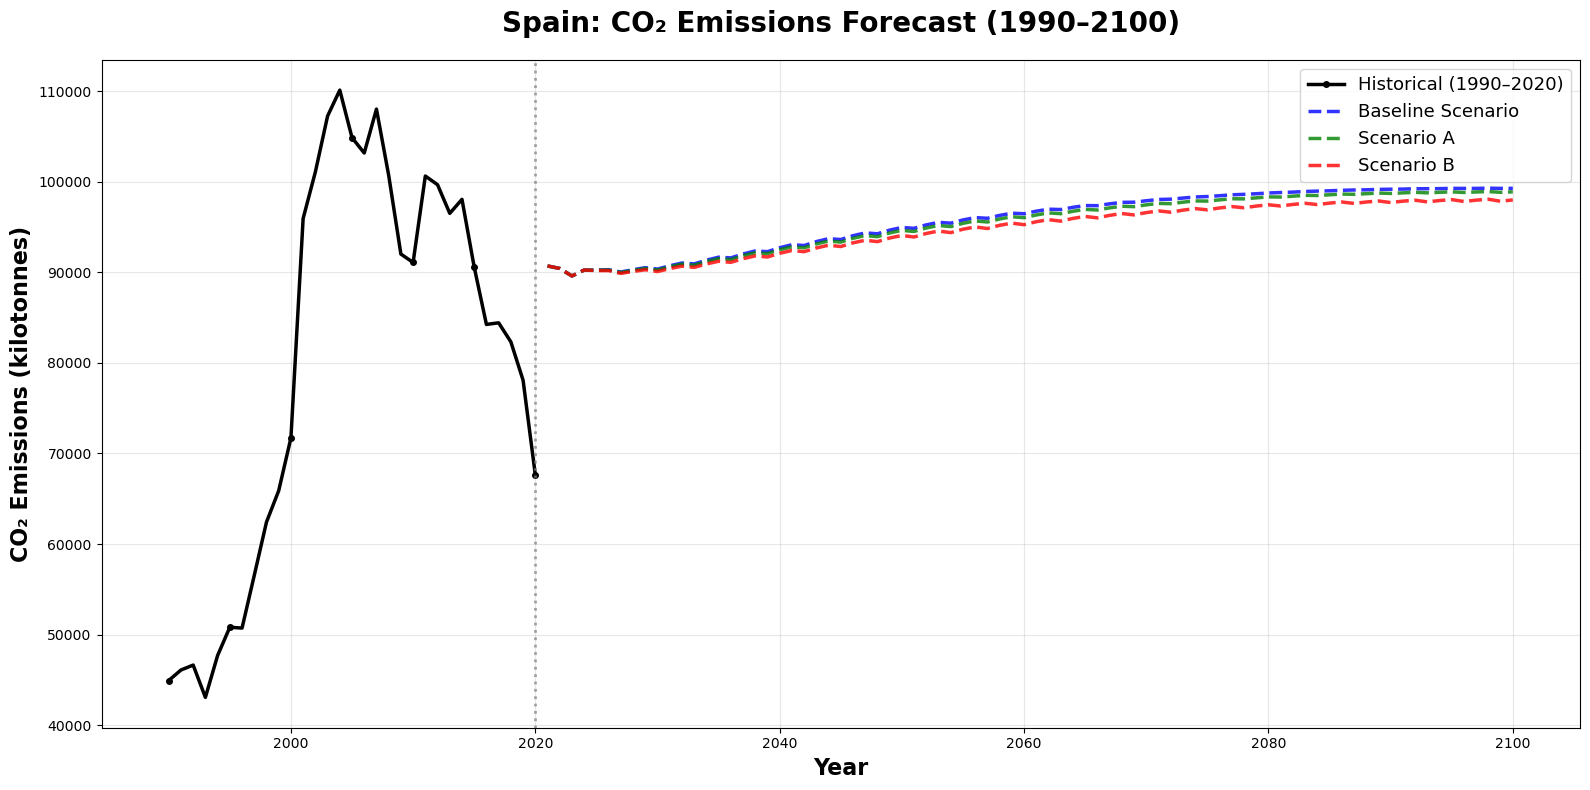

✅ Saved: spain_emissions_1990_2100.png


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================================
# LOAD DATA
# =====================================================================

df_hist = pd.read_csv("Agrofood_co2_emission_clean.csv")

forecast_A = pd.read_csv("tft_forecast_scenarioA_2021_2100.csv")
forecast_B = pd.read_csv("tft_forecast_scenarioB_2021_2100.csv")
forecast_Base = pd.read_csv("tft_forecast_baseline_2021_2100.csv")


# =====================================================================
# FUNCTION TO PLOT FOR ANY COUNTRY
# =====================================================================

def plot_country(country):

    # ------------------------- #
    # Filter historical & forecasts
    # ------------------------- #
    hist = df_hist[df_hist["Area"] == country].sort_values("Year")
    base = forecast_Base[forecast_Base["Area"] == country].sort_values("Year")
    A = forecast_A[forecast_A["Area"] == country].sort_values("Year")
    B = forecast_B[forecast_B["Area"] == country].sort_values("Year")

    plt.figure(figsize=(16, 8))

    # Historical
    plt.plot(
        hist["Year"], hist["total_emission"],
        color="black", linewidth=2.5, label="Historical (1990–2020)",
        marker='o', markersize=4, markevery=5
    )

    # Baseline Forecast
    plt.plot(
        base["Year"], base["predicted_emissions"],
        color="blue", linestyle="--", linewidth=2.5, alpha=0.8,
        label="Baseline Scenario"
    )

    # Scenario A
    plt.plot(
        A["Year"], A["predicted_emissions"],
        color="green", linestyle="--", linewidth=2.5, alpha=0.8,
        label="Scenario A"
    )

    # Scenario B
    plt.plot(
        B["Year"], B["predicted_emissions"],
        color="red", linestyle="--", linewidth=2.5, alpha=0.8,
        label="Scenario B"
    )

    # Forecast boundary
    plt.axvline(x=2020, color="gray", linestyle=":", linewidth=2, alpha=0.7)

    # Title & labels
    plt.title(f"{country}: CO₂ Emissions Forecast (1990–2100)",
              fontsize=20, fontweight='bold', pad=20)

    plt.xlabel("Year", fontsize=16, fontweight='bold')
    plt.ylabel("CO₂ Emissions (kilotonnes)", fontsize=16, fontweight='bold')

    plt.legend(fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save image
    fname = f"{country.lower().replace(' ', '_')}_emissions_1990_2100.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Saved: {fname}")


# =====================================================================
# PLOT FOR AFGHANISTAN & BRAZIL
# =====================================================================

plot_country("China")
plot_country("United States of America")
plot_country("Spain")
